# Classification Evaluation Metrics

#### The Confusion Matrix and Basic Metrics
##### Dataset: from sklearn.datasets import load_breast_cancer
##### Task: Take the predictions from any of your intermediate models above.
##### Action: Generate a Confusion Matrix. From the matrix values, manually calculate the Accuracy, Precision, Recall, and F1-Score using Python math, and then verify your answers using sklearn.metrics.classification_report.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, min_samples_split=10, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
print("Confusion Matrix:")
print(cm)

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f"\nManual Calculation:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nVerification via classification_report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Confusion Matrix:
[[51  3]
 [ 4 85]]

Manual Calculation:
Accuracy : 0.9510
Precision: 0.9659
Recall   : 0.9551
F1-Score : 0.9605

Verification via classification_report:
              precision    recall  f1-score   support

   malignant       0.93      0.94      0.94        54
      benign       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



#### The ROC Curve and AUC
##### Dataset: from sklearn.datasets import load_breast_cancer
##### Task: Train a classifier that outputs probabilities (like Logistic Regression or Random Forest) on a binary classification dataset.
##### Action: Extract the predicted probabilities (predict_proba) rather than the absolute class predictions. Use these probabilities to plot a Receiver Operating Characteristic (ROC) curve. Calculate and display the Area Under the Curve (AUC) score on the plot. Explain what the curve represents regarding True Positive vs. False Positive trade-offs.

AUC: 0.9977


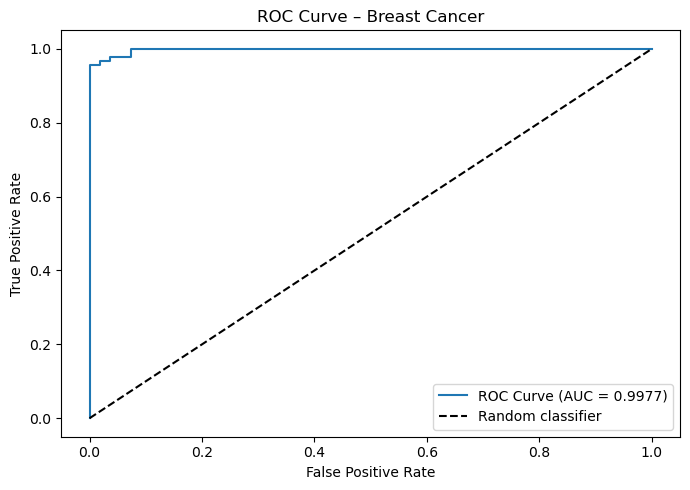

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

clf = LogisticRegression(max_iter=10000, random_state=42)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Breast Cancer")
plt.legend()
plt.tight_layout()
plt.savefig("roc.png", dpi=150)
print(f"AUC: {roc_auc:.4f}")